# Home Credit Default Risk
## https://www.kaggle.com/datasets/megancrenshaw/home-credit-default-risk

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Toda la base de datos

In [9]:
df = pd.read_csv('application_train.csv')

In [10]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Cargamos solo las columnas más relevantes

In [11]:

def load_home_credit_data(file_path):
    cols = [
        'TARGET', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
        'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
    ]

    df = pd.read_csv(file_path, usecols=cols)

    # Preprocesado rápido
    # 1. Convertir género a numérico (Variable Sensible)
    df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1}).fillna(0)

    # 2. Edad a años positivos
    df['DAYS_BIRTH'] = abs(df['DAYS_BIRTH']) / 365

    # 3. Tratar valores nulos en fuentes externas (clave para la incertidumbre)
    for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
        df[col] = df[col].fillna(df[col].median())

    # Separar variables
    X = df.drop(columns=['TARGET'])
    y = df['TARGET']
    s = df['CODE_GENDER'] # Guardamos la variable sensible aparte para la Loss Custom

    # Split
    X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(
        X, y, s, test_size=0.2, random_state=42
    )

    # Escalado
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return (X_train, y_train, s_train), (X_test, y_test, s_test)



In [12]:
# Uso:
(X_train, y_train, s_train), (X_test, y_test, s_test) = load_home_credit_data('application_train.csv')

In [13]:
import numpy as np

# Ensure y_train and s_train are 2D arrays for stacking
y_train_reshaped = y_train.values.reshape(-1, 1)

# Combine X_train, y_train, and s_train into a single matrix
combined_data_train = np.hstack((X_train, y_train_reshaped))

print("Shape of the combined training data matrix:", combined_data_train.shape)
print("First 5 rows of the combined training data matrix:\n", combined_data_train[:5,:])

Shape of the combined training data matrix: (246008, 9)
First 5 rows of the combined training data matrix:
 [[ 0.72106056  0.02430965 -0.11006828 -0.74109349  1.67613559  0.14518024
  -0.81696045  0.27469408  0.        ]
 [-1.38684607 -0.10484026 -0.99617411 -0.2399438  -1.17349864 -1.86232543
  -0.12674396  0.4556939   0.        ]
 [-1.38684607 -0.32009011  0.43826238 -0.13419378  1.64495195  0.0110865
   0.67540116  1.08962181  1.        ]
 [-1.38684607 -0.04138461  0.74512571  0.66621918 -1.22348418 -1.54862838
  -0.46140535 -0.05358255  0.        ]
 [-1.38684607  0.54090928 -0.16366442 -0.40151496 -0.0552442   2.05055166
  -0.36044038  0.0701048   0.        ]]


In [14]:
print(X_train.shape)
print(y_train.shape)
print(s_train.shape)
print(combined_data_train.shape)

(246008, 8)
(246008,)
(246008,)
(246008, 9)


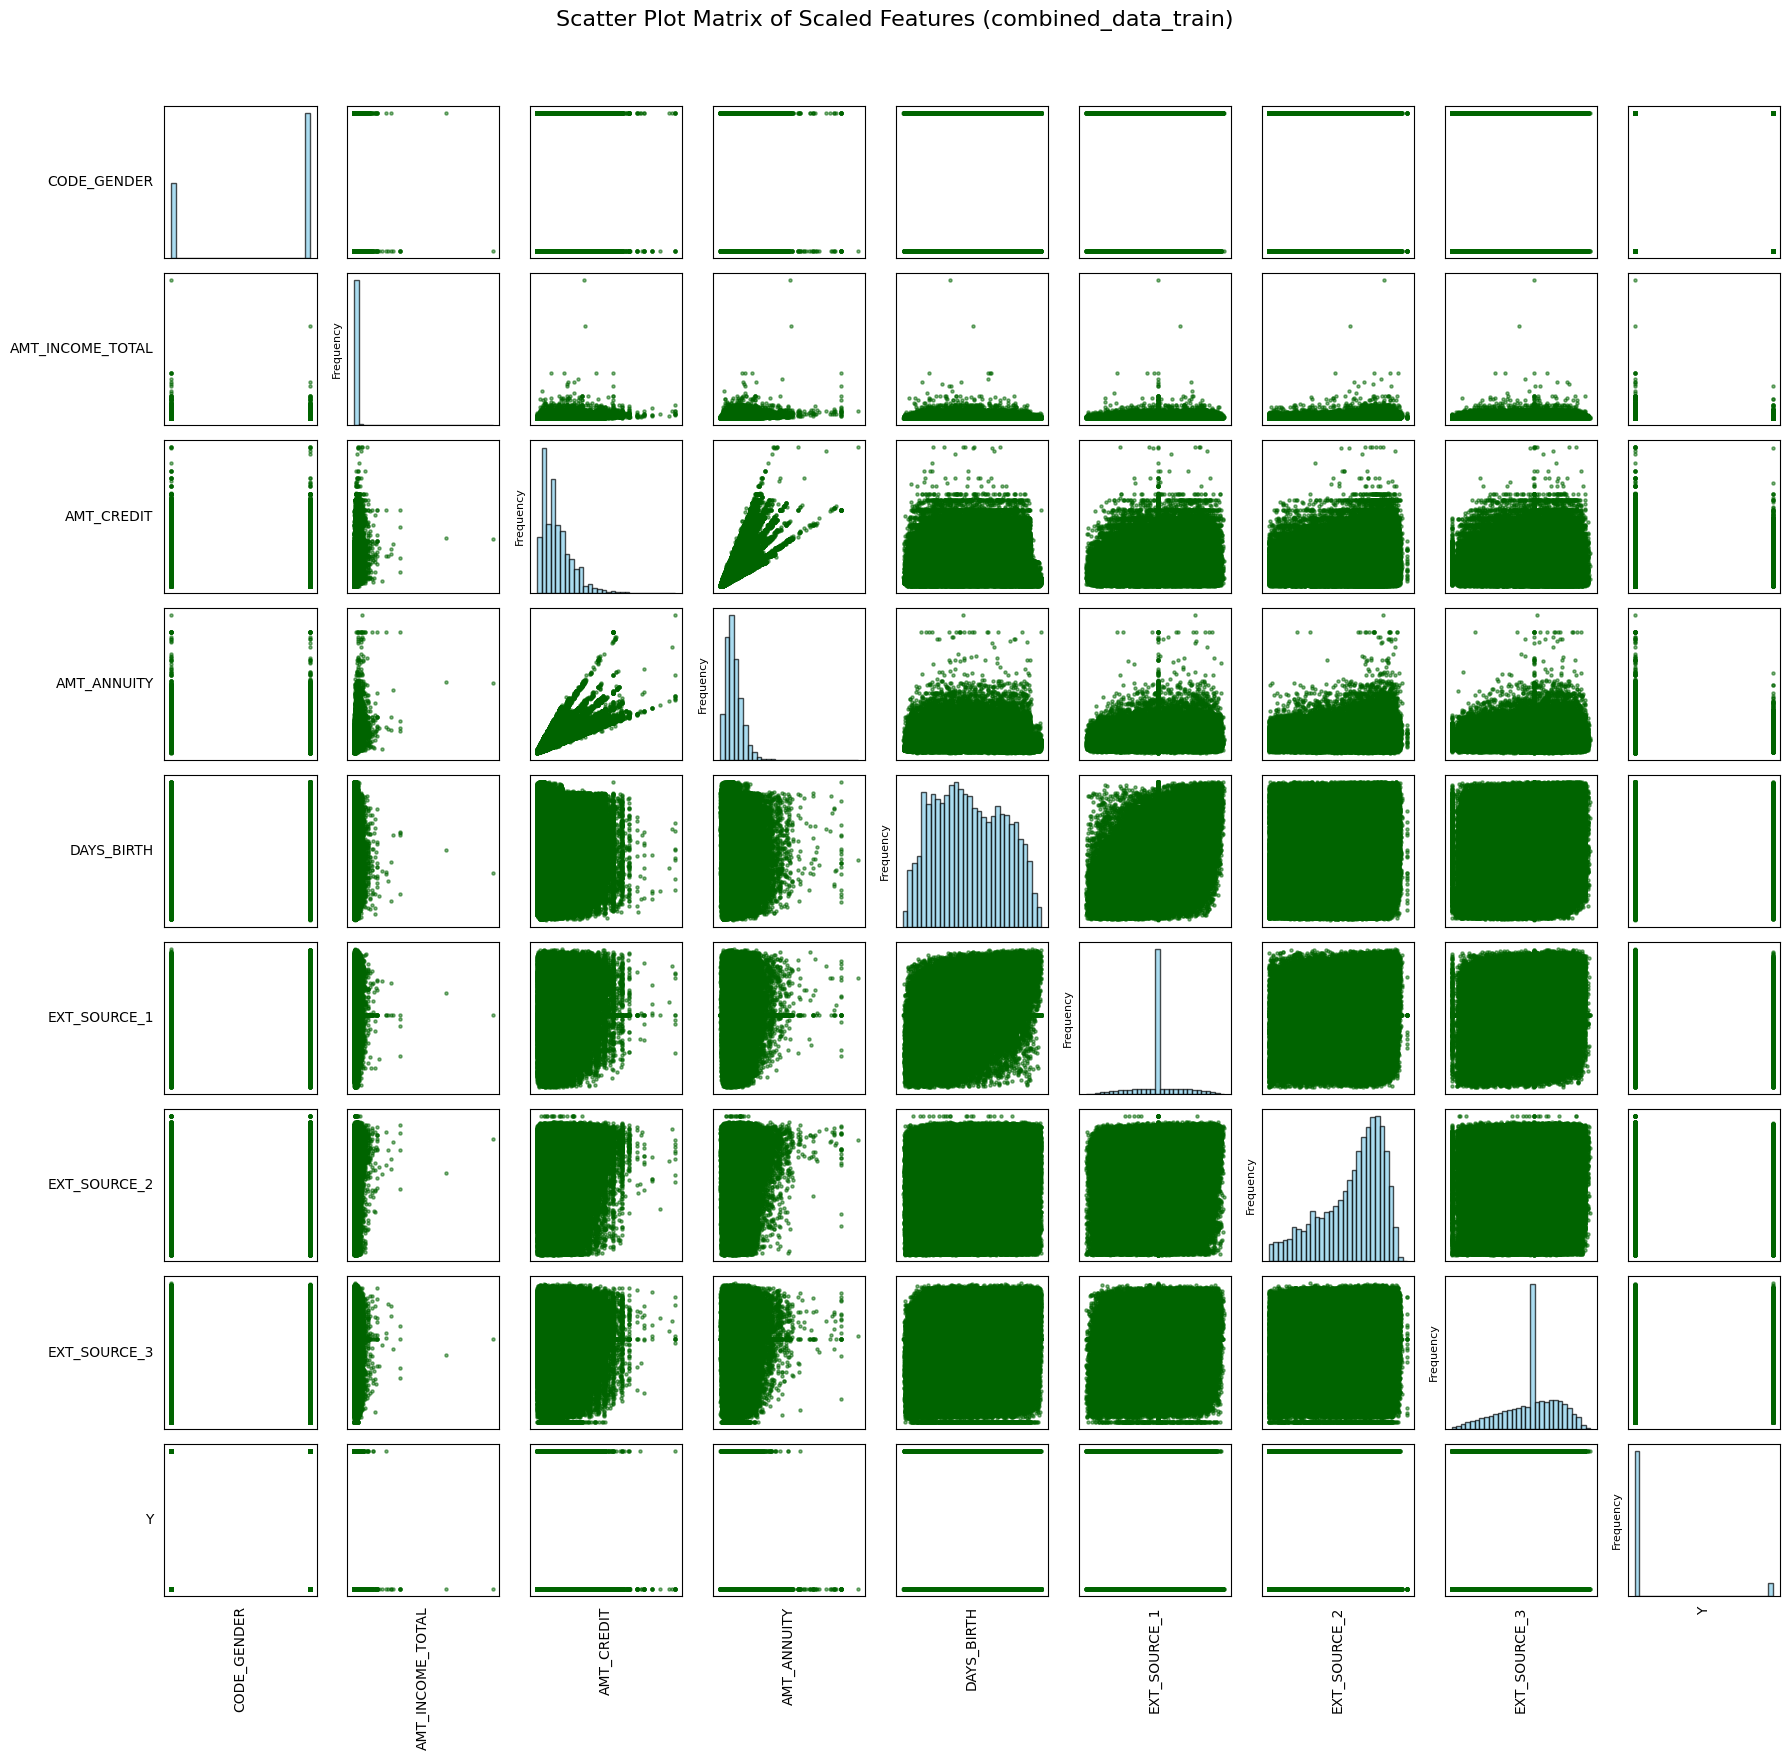

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Reconstruct column names for better labels, assuming the order from load_home_credit_data function
feature_names = [
    'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3','Y'
]

n_features = combined_data_train.shape[1]
fig, axes = plt.subplots(n_features, n_features, figsize=(18, 18))

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]
        if i == j:
            # On diagonal, plot histogram
            ax.hist(combined_data_train[:, i], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
            ax.set_ylabel('Frequency', fontsize=8)
        else:
            # Off-diagonal, plot scatter plot
            ax.scatter(combined_data_train[:, j], combined_data_train[:, i], alpha=0.5, s=5, color='darkgreen')
            ax.set_aspect('auto')

        # Set labels for the outer plots only
        if i == n_features - 1: # Bottom row
            ax.set_xlabel(feature_names[j], rotation=90, ha='center', fontsize=10)
        else:
            ax.set_xticks([])

        if j == 0: # Leftmost column
            ax.set_ylabel(feature_names[i], rotation=0, ha='right', va='center', fontsize=10)
        else:
            ax.set_yticks([])

        # Remove ticks for all inner plots
        ax.tick_params(axis='both', which='both', length=0)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

plt.suptitle('Scatter Plot Matrix of Scaled Features (combined_data_train)', y=1.005, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# EDA


              TARGET  AMT_INCOME_TOTAL    AMT_CREDIT    AMT_ANNUITY  \
count  307511.000000      3.075110e+05  3.075110e+05  307499.000000   
mean        0.080729      1.687979e+05  5.990260e+05   27108.573909   
std         0.272419      2.371231e+05  4.024908e+05   14493.737315   
min         0.000000      2.565000e+04  4.500000e+04    1615.500000   
25%         0.000000      1.125000e+05  2.700000e+05   16524.000000   
50%         0.000000      1.471500e+05  5.135310e+05   24903.000000   
75%         0.000000      2.025000e+05  8.086500e+05   34596.000000   
max         1.000000      1.170000e+08  4.050000e+06  258025.500000   

          DAYS_BIRTH   EXT_SOURCE_1  EXT_SOURCE_2   EXT_SOURCE_3  
count  307511.000000  134133.000000  3.068510e+05  246546.000000  
mean   -16036.995067       0.502130  5.143927e-01       0.510853  
std      4363.988632       0.211062  1.910602e-01       0.194844  
min    -25229.000000       0.014568  8.173617e-08       0.000527  
25%    -19682.000000     

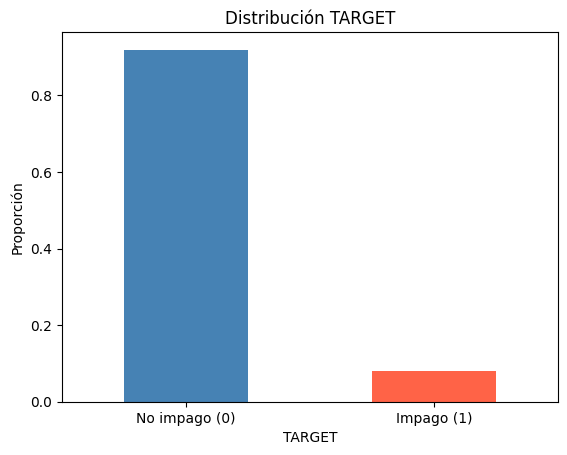

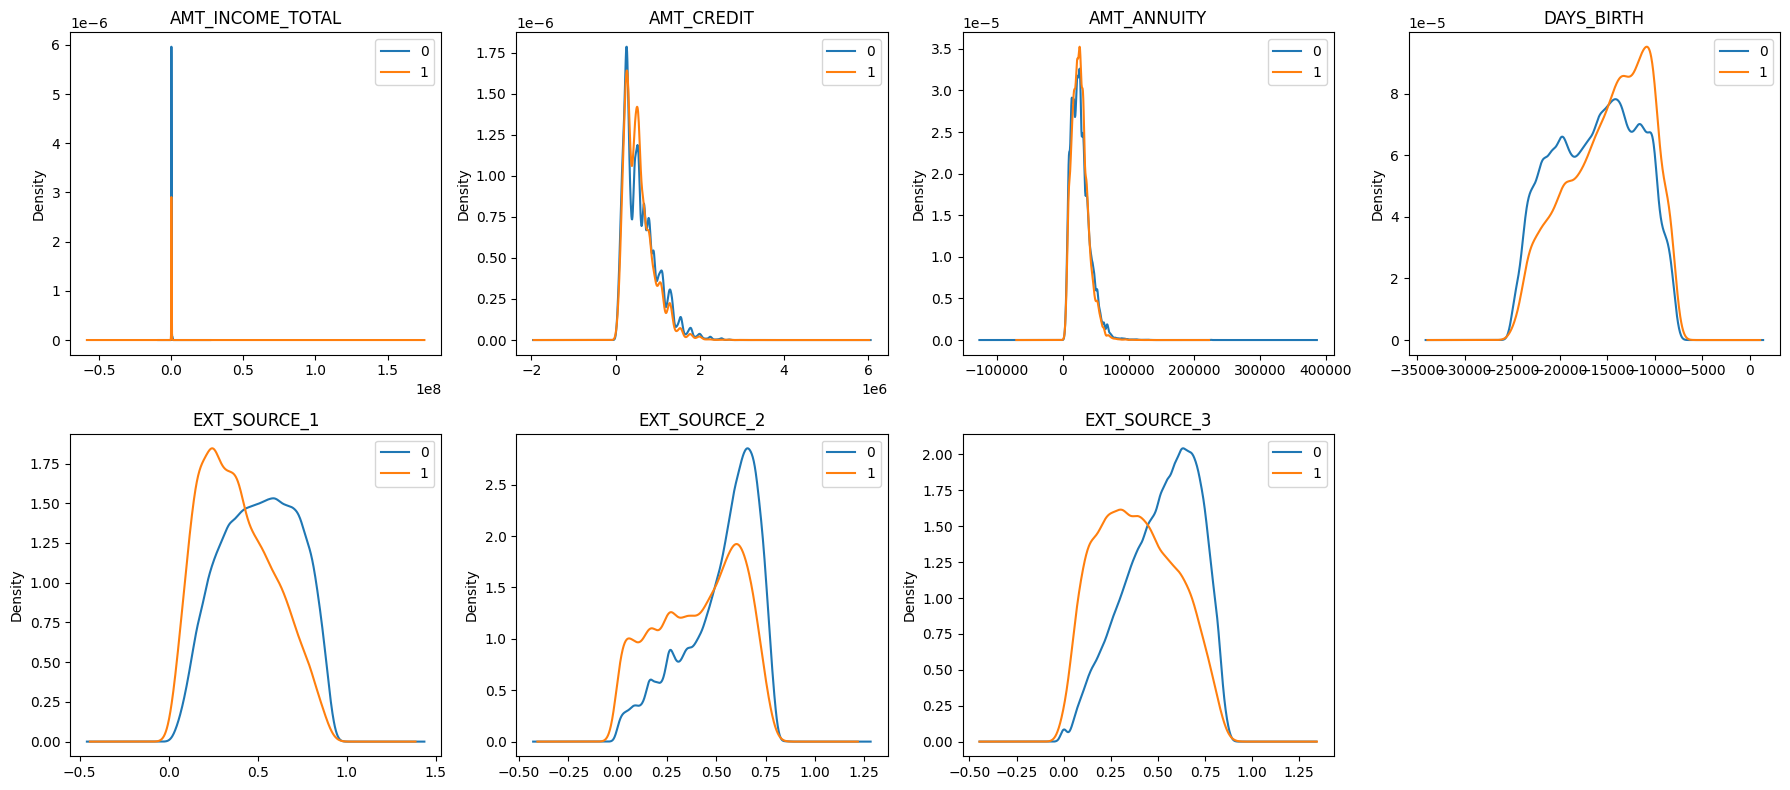

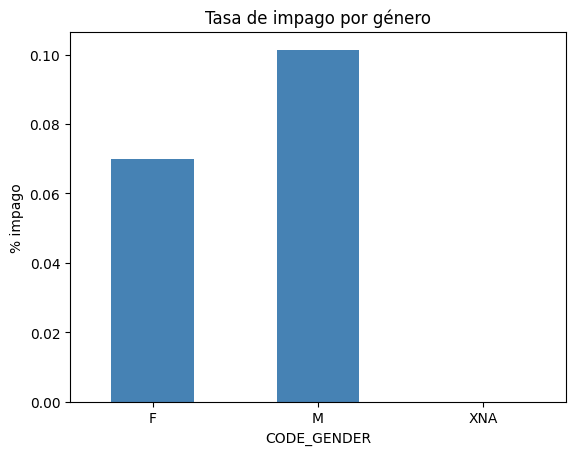

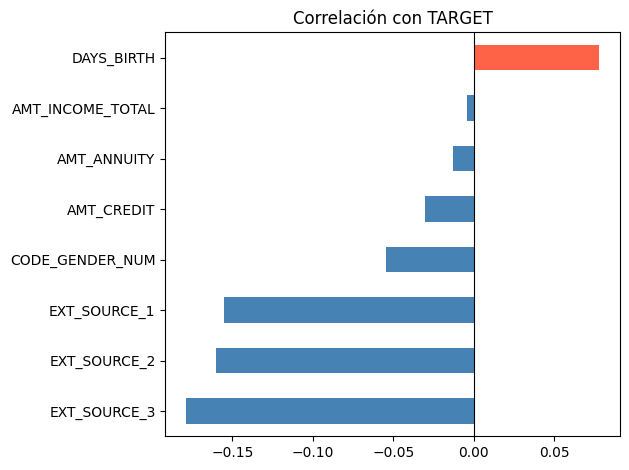

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['TARGET', 'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
        'AMT_ANNUITY', 'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

df = pd.read_csv('application_train.csv', usecols=cols)

# ── 1. RESUMEN BÁSICO ─────────────────────────────────────────────────────────
print(df.describe())
print("\nNulos:\n", df.isnull().sum())

# ── 2. TARGET ─────────────────────────────────────────────────────────────────
df['TARGET'].value_counts(normalize=True).plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Distribución TARGET')
plt.ylabel('Proporción')
plt.xticks([0,1], ['No impago (0)', 'Impago (1)'], rotation=0)
plt.show()

# ── 3. KDE de numéricas por TARGET ───────────────────────────────────────────
num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
            'DAYS_BIRTH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), num_cols):
    df.groupby('TARGET')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.show()

# ── 4. TASA DE IMPAGO POR GÉNERO ─────────────────────────────────────────────
df.groupby('CODE_GENDER')['TARGET'].mean().plot(kind='bar', color='steelblue')
plt.title('Tasa de impago por género')
plt.ylabel('% impago')
plt.xticks(rotation=0)
plt.show()

# ── 5. CORRELACIÓN CON TARGET ─────────────────────────────────────────────────
df['CODE_GENDER_NUM'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})
corr = df.drop(columns='CODE_GENDER').corrwith(df['TARGET']).drop('TARGET').sort_values()
corr.plot(kind='barh', color=['tomato' if v > 0 else 'steelblue' for v in corr])
plt.title('Correlación con TARGET')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


# Capa customizada

Capa DebtRatioLayer — resumen

Calcula dos ratios financieros: endeudamiento (AMT_CREDIT / AMT_INCOME_TOTAL) y esfuerzo (AMT_ANNUITY / AMT_INCOME_TOTAL).

Aplica una penalización cuadrática a partir de un umbral: lineal hasta el umbral, cuadrático por encima
El umbral es trainable: la red aprende durante el entrenamiento a partir de qué ratio el riesgo escala de forma no lineal.

Se usa softplus en lugar de relu porque el umbral necesita recibir gradientes para poder aprender.

La capa añade los 2 ratios procesados al input original (8 → 10 features) antes de las capas densas

In [38]:
import tensorflow as tf
from tensorflow import keras

class DebtRatioLayer(keras.layers.Layer):

    def build(self, input_shape):
        self.threshold_deuda = self.add_weight(
            name='threshold_deuda',
            shape=(),
            initializer=tf.constant_initializer(3.0),
            constraint=keras.constraints.NonNeg(),
            trainable=True
        )
        self.threshold_esfuerzo = self.add_weight(
            name='threshold_esfuerzo',
            shape=(),
            initializer=tf.constant_initializer(0.3),
            constraint=keras.constraints.NonNeg(),
            trainable=False
        )
        super().build(input_shape)

    def _penalize(self, ratio, threshold):
        excess = tf.nn.softplus(ratio - threshold)
        return ratio + tf.square(excess)

    def call(self, inputs):
        income  = inputs[:, 1:2]
        credit  = inputs[:, 2:3]
        annuity = inputs[:, 3:4]

        denom = tf.abs(income) + 1e-7

        ratio_deuda    = tf.clip_by_value(credit  / denom, -5.0, 5.0)
        ratio_esfuerzo = tf.clip_by_value(annuity / denom, -5.0, 5.0)

        r1 = self._penalize(ratio_deuda,    self.threshold_deuda)
        r2 = self._penalize(ratio_esfuerzo, self.threshold_esfuerzo)

        return tf.concat([inputs, r1, r2], axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[1] + 2)


# Función de pérdida customizada

In [ ]:
lambda_fair = 0.1

# ── CKA HELPERS ───────────────────────────────────────────────────────────────
def center_kernel(K):
    """H @ K @ H  —  centra la matriz kernel"""
    row_mean   = keras.ops.mean(K, axis=1, keepdims=True)
    col_mean   = keras.ops.mean(K, axis=0, keepdims=True)
    total_mean = keras.ops.mean(K)
    return K - row_mean - col_mean + total_mean

def hsic(K, L):
    n = keras.ops.cast(keras.ops.shape(K)[0], 'float32')
    return keras.ops.sum(center_kernel(K) * center_kernel(L)) / (n ** 2)

def cka(x, y):
    x = keras.ops.reshape(x, (-1, 1))
    y = keras.ops.reshape(y, (-1, 1))
    K = x @ keras.ops.transpose(x)
    L = y @ keras.ops.transpose(y)
    return hsic(K, L) / keras.ops.sqrt(hsic(K, K) * hsic(L, L) + 1e-3)  # 1e-7 → 1e-3

# ── FAIR LOSS CON CKA ─────────────────────────────────────────────────────────
def fair_loss_cka(y_combined, y_pred):

    y_true = y_combined[:, 0:1]
    s      = keras.ops.cast(y_combined[:, 1:2], 'float32')

    # Error de clasificación
    bce = keras.ops.mean(
        keras.ops.binary_crossentropy(y_true, y_pred)
    )

    # Penalización CKA: similitud entre predicciones y género
    # CKA = 0 → independientes (justo)
    # CKA = 1 → totalmente dependientes (injusto)
    cka_penalty = cka(y_pred, s)

    return bce + lambda_fair * cka_penalty


# Eligiendo el modelo con Keras Tuner

In [39]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras
import numpy as np
import shutil, os

# ── MÉTRICAS ──────────────────────────────────────────────────────────────────
class FairAUC(keras.metrics.AUC):
    """AUC extrayendo solo TARGET de y_combined"""
    def update_state(self, y_true, y_pred, sample_weight=None):
        return super().update_state(y_true[:, 0:1], y_pred, sample_weight)

class DeltaGenero(keras.metrics.Metric):
    """Diferencia en tasa de predicción positiva entre géneros"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.suma_h  = self.add_weight(initializer='zeros')
        self.suma_m  = self.add_weight(initializer='zeros')
        self.count_h = self.add_weight(initializer='zeros')
        self.count_m = self.add_weight(initializer='zeros')

    def update_state(self, y_combined, y_pred, sample_weight=None):
        s      = keras.ops.cast(y_combined[:, 1:2], 'float32')
        mask_h = keras.ops.cast(keras.ops.equal(s, 0), 'float32')
        mask_m = keras.ops.cast(keras.ops.equal(s, 1), 'float32')
        self.suma_h.assign_add(keras.ops.sum(y_pred * mask_h))
        self.suma_m.assign_add(keras.ops.sum(y_pred * mask_m))
        self.count_h.assign_add(keras.ops.sum(mask_h))
        self.count_m.assign_add(keras.ops.sum(mask_m))

    def result(self):
        return keras.ops.abs(
            self.suma_h / (self.count_h + 1e-7) -
            self.suma_m / (self.count_m + 1e-7)
        )

    def reset_state(self):
        for w in [self.suma_h, self.suma_m, self.count_h, self.count_m]:
            w.assign(0.)


# ── BUILD MODEL ───────────────────────────────────────────────────────────────
def build_model(hp):
    inputs = keras.Input(shape=(8,))
    x = DebtRatioLayer()(inputs)

    for i in range(hp.Int('num_layers', 1, 3)):
        x = keras.layers.Dense(
            units=hp.Choice(f'units_{i}', [32, 64, 128]),
            activation='relu'
        )(x)
        x = keras.layers.Dropout(
            rate=hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)
        )(x)

    output = keras.layers.Dense(1, activation='sigmoid')(x)
    model  = keras.Model(inputs, output)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('lr', [1e-3, 1e-4]),
            clipvalue=0.1   # ← evita explosión de gradientes
        ),

        loss=fair_loss_cka,
        metrics=[DeltaGenero(name='delta_genero')]
    )
    return model



# ── BÚSQUEDA ──────────────────────────────────────────────────────────────────
if os.path.exists('kt_results'):
    shutil.rmtree('kt_results')

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',       # ← minimiza fair_loss_cka directamente
    max_trials=1,
    directory='kt_results',
    project_name='home_credit_fair'
)

tuner.search(
    X_train, y_train_fair,
    epochs=50,
    batch_size=256,
    validation_data=(X_test, y_test_fair),
    callbacks=[keras.callbacks.EarlyStopping(
        monitor='val_loss',     # ← coherente con el objetivo
        mode='min',
        patience=25,
        restore_best_weights=True
    )],
    class_weight={0: 1, 1: 12},
    verbose=1
)


# ── RESULTADOS ────────────────────────────────────────────────────────────────
best_hp    = tuner.get_best_hyperparameters()[0]
best_model = tuner.get_best_models()[0]

print("Mejores hiperparámetros:")
print(f"  Capas: {best_hp.get('num_layers')}")
for i in range(best_hp.get('num_layers')):
    print(f"  Capa {i} — units: {best_hp.get(f'units_{i}')}, "
          f"dropout: {best_hp.get(f'dropout_{i}')}")
print(f"  LR: {best_hp.get('lr')}")

debt_layer = best_model.layers[1]
print(f"\nUmbral endeudamiento: {debt_layer.threshold_deuda.numpy():.2f}x ingreso")
print(f"Umbral esfuerzo:      {debt_layer.threshold_esfuerzo.numpy():.2%} del ingreso")


Trial 1 Complete [00h 01m 08s]
val_loss: 0.2799098789691925

Best val_loss So Far: 0.2799098789691925
Total elapsed time: 00h 01m 08s
Mejores hiperparámetros:
  Capas: 1
  Capa 0 — units: 32, dropout: 0.2
  LR: 0.0001

Umbral endeudamiento: 3.00x ingreso
Umbral esfuerzo:      30.00% del ingreso


C:\Users\bogar\AppData\Roaming\Python\Python313\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
